# Avance 2 — Equipo #48

![Tecnológico de Monterrey](https://i.imgur.com/tHk1B4P.png)

**Febrero 01, 2026**

| Nombre | Matrícula |
|--------|-----------|
| Jorge Daniel Amezola González | A01793759 |
| Diego Alejandro del Valle Pimentel | A01747310 |
| José Santiago Rueda Antonio | A01794118 |

---
## 2. Configuración Inicial

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from collections import Counter
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [21]:
# ============================================================
# CONFIGURACIÓN DEL DATASET
# ============================================================

# PASTIS_PATH = Path("/home/jsant16/proyecto-integrador/dataset/PASTIS-R")
PASTIS_PATH = Path(r"../PASTIS-R")

# 20 clases de cultivos agrícolas
CLASSES = {
    0: "Background",           # Fondo (no es cultivo)
    1: "Meadow",               # Pradera/Pasto
    2: "Soft winter wheat",    # Trigo blando de invierno
    3: "Corn",                 # Maíz
    4: "Winter barley",        # Cebada de invierno
    5: "Winter rapeseed",      # Colza de invierno
    6: "Spring barley",        # Cebada de primavera
    7: "Sunflower",            # Girasol
    8: "Grapevine",            # Vid/Viñedo
    9: "Beet",                 # Remolacha
    10: "Winter triticale",    # Triticale de invierno
    11: "Winter durum wheat",  # Trigo duro de invierno
    12: "Fruits/veg/flowers",  # Frutas/Verduras/Flores
    13: "Potatoes",            # Papas
    14: "Leguminous fodder",   # Forraje de leguminosas
    15: "Soybeans",            # Soya
    16: "Orchard",             # Huerto frutal
    17: "Mixed cereal",        # Cereal mixto
    18: "Sorghum",             # Sorgo
    19: "Void/Mixed"           # Vacío/Mixto (sin clasificar)
}

# Bandas espectrales de Sentinel-2 (10 bandas)
# Cada banda captura una longitud de onda diferente
S2_BANDS_INFO = {
    'B2':  {'nombre': 'Azul',           'longitud_onda': '490 nm',  'uso': 'Color visible'},
    'B3':  {'nombre': 'Verde',          'longitud_onda': '560 nm',  'uso': 'Color visible'},
    'B4':  {'nombre': 'Rojo',           'longitud_onda': '665 nm',  'uso': 'Color visible'},
    'B5':  {'nombre': 'Red Edge 1',     'longitud_onda': '705 nm',  'uso': 'Transición vegetación'},
    'B6':  {'nombre': 'Red Edge 2',     'longitud_onda': '740 nm',  'uso': 'Contenido clorofila'},
    'B7':  {'nombre': 'Red Edge 3',     'longitud_onda': '783 nm',  'uso': 'Contenido clorofila'},
    'B8':  {'nombre': 'NIR',            'longitud_onda': '842 nm',  'uso': 'Salud vegetación'},
    'B8A': {'nombre': 'NIR estrecho',   'longitud_onda': '865 nm',  'uso': 'Biomasa'},
    'B11': {'nombre': 'SWIR 1',         'longitud_onda': '1610 nm', 'uso': 'Humedad suelo/planta'},
    'B12': {'nombre': 'SWIR 2',         'longitud_onda': '2190 nm', 'uso': 'Discriminar minerales'}
}
S2_BANDS = list(S2_BANDS_INFO.keys())

# Canales de Sentinel-1 (SAR - Radar)
S1_CHANNELS_INFO = {
    'VV':    'Polarización Vertical-Vertical (sensible a estructura vertical)',
    'VH':    'Polarización Vertical-Horizontal (sensible a volumen de vegetación)',
    'VV/VH': 'Ratio entre VV y VH (útil para discriminar tipos de cobertura)'
}
S1_CHANNELS = list(S1_CHANNELS_INFO.keys())

print(f"📁 Dataset: {PASTIS_PATH}")
print(f"🌾 {len(CLASSES)} clases de cultivos")
print(f"🛰️ {len(S2_BANDS)} bandas Sentinel-2 (óptico)")
print(f"📡 {len(S1_CHANNELS)} canales Sentinel-1 (radar)")

📁 Dataset: ..\PASTIS-R
🌾 20 clases de cultivos
🛰️ 10 bandas Sentinel-2 (óptico)
📡 3 canales Sentinel-1 (radar)


In [22]:
def load_patch(patch_id, data_path=PASTIS_PATH):
    """
    Carga todos los datos de un patch (parcela).
    
    Retorna un diccionario con:
    - s2: Imágenes Sentinel-2 (T, 10, 128, 128) - T timestamps, 10 bandas
    - s1a: Imágenes Sentinel-1 Ascending (T, 3, 128, 128)
    - s1d: Imágenes Sentinel-1 Descending (T, 3, 128, 128)
    - annotations: Máscaras de segmentación (3, 128, 128)
    """
    data = {'id': patch_id}
    
    # Sentinel-2 (óptico)
    s2_file = data_path / "DATA_S2" / f"S2_{patch_id}.npy"
    if s2_file.exists():
        data['s2'] = np.load(s2_file)
    
    # Sentinel-1 Ascending (radar, órbita ascendente)
    s1a_file = data_path / "DATA_S1A" / f"S1A_{patch_id}.npy"
    if s1a_file.exists():
        data['s1a'] = np.load(s1a_file)
    
    # Sentinel-1 Descending (radar, órbita descendente)
    s1d_file = data_path / "DATA_S1D" / f"S1D_{patch_id}.npy"
    if s1d_file.exists():
        data['s1d'] = np.load(s1d_file)
    
    # Anotaciones (etiquetas de clase por píxel)
    annot_file = data_path / "ANNOTATIONS" / f"TARGET_{patch_id}.npy"
    if annot_file.exists():
        data['annotations'] = np.load(annot_file)
    
    return data


def get_patch_ids(data_path=PASTIS_PATH):
    """Obtiene la lista de todos los IDs de patches disponibles."""
    s2_files = sorted((data_path / "DATA_S2").glob("S2_*.npy"))
    return [int(f.stem.split('_')[1]) for f in s2_files]


patch_ids = get_patch_ids()
print(f"\n📦 Total de patches en el dataset: {len(patch_ids):,}")


📦 Total de patches en el dataset: 2,468


In [23]:
# Estructura de carpetas del dataset
print("📂 ESTRUCTURA DEL DATASET PASTIS-R:")
print("=" * 60)
for item in sorted(PASTIS_PATH.iterdir()):
    if item.is_dir():
        n_files = len(list(item.glob("*")))
        print(f"📁 {item.name:25s} → {n_files:,} archivos")
    else:
        print(f"📄 {item.name}")

print("\n" + "=" * 60)
print("📝 DESCRIPCIÓN DE CARPETAS:")
print("   • DATA_S2:     Imágenes ópticas Sentinel-2 (series temporales)")
print("   • DATA_S1A:    Imágenes radar Sentinel-1 órbita ascendente")
print("   • DATA_S1D:    Imágenes radar Sentinel-1 órbita descendente")
print("   • ANNOTATIONS: Etiquetas de clase para cada píxel (ground truth)")
print("   • NORM_*.json: Estadísticas de normalización precalculadas")

📂 ESTRUCTURA DEL DATASET PASTIS-R:
📁 ANNOTATIONS               → 4,867 archivos
📁 DATA_S1A                  → 2,468 archivos
📁 DATA_S1D                  → 2,468 archivos
📁 DATA_S2                   → 2,468 archivos
📁 INSTANCE_ANNOTATIONS      → 7,299 archivos
📄 metadata.geojson
📄 NORM_S1A_patch.json
📄 NORM_S1D_patch.json
📄 NORM_S2_patch.json

📝 DESCRIPCIÓN DE CARPETAS:
   • DATA_S2:     Imágenes ópticas Sentinel-2 (series temporales)
   • DATA_S1A:    Imágenes radar Sentinel-1 órbita ascendente
   • DATA_S1D:    Imágenes radar Sentinel-1 órbita descendente
   • ANNOTATIONS: Etiquetas de clase para cada píxel (ground truth)
   • NORM_*.json: Estadísticas de normalización precalculadas


In [24]:
# Inspeccionar un patch de ejemplo
sample = load_patch(patch_ids[0])

print(f"\n🔍 ESTRUCTURA DE UN PATCH (ID: {sample['id']}):")
print("=" * 60)

for key, val in sample.items():
    if isinstance(val, np.ndarray):
        print(f"\n   📊 {key.upper()}:")
        print(f"      Dimensiones: {val.shape}")
        print(f"      Tipo de dato: {val.dtype}")
        
        if key == 's2':
            print(f"      → {val.shape[0]} timestamps (fechas de captura)")
            print(f"      → {val.shape[1]} bandas espectrales")
            print(f"      → {val.shape[2]}x{val.shape[3]} píxeles (≈1.28 km²)")
        elif key in ['s1a', 's1d']:
            print(f"      → {val.shape[0]} timestamps")
            print(f"      → {val.shape[1]} canales de polarización (VV, VH, VV/VH)")
        elif key == 'annotations':
            print("      → Capa 0: Máscara semántica (clase de cultivo por píxel)")


🔍 ESTRUCTURA DE UN PATCH (ID: 10000):

   📊 S2:
      Dimensiones: (43, 10, 128, 128)
      Tipo de dato: int16
      → 43 timestamps (fechas de captura)
      → 10 bandas espectrales
      → 128x128 píxeles (≈1.28 km²)

   📊 S1A:
      Dimensiones: (65, 3, 128, 128)
      Tipo de dato: float16
      → 65 timestamps
      → 3 canales de polarización (VV, VH, VV/VH)

   📊 S1D:
      Dimensiones: (70, 3, 128, 128)
      Tipo de dato: float16
      → 70 timestamps
      → 3 canales de polarización (VV, VH, VV/VH)

   📊 ANNOTATIONS:
      Dimensiones: (3, 128, 128)
      Tipo de dato: uint8
      → Capa 0: Máscara semántica (clase de cultivo por píxel)


In [25]:
def patch_to_dataframe(patch_id):
    
    patch = load_patch(patch_id)
    try:
        s2 = patch["s2"]       
        labels = patch["annotations"] 
    except:
        return pd.DataFrame()
    
    # -------- REDUCCIÓN TEMPORAL --------
    mean = np.mean(s2, axis=0)
    std = np.std(s2, axis=0)
    max_val = np.max(s2, axis=0)
    
    # -------- NDVI --------
    red = mean[3]  
    nir = mean[7]   
    
    ndvi = (nir - red) / (nir + red + 1e-6)
    
    # -------- STACK FEATURES --------
    features = np.vstack([
        mean.reshape(10, -1),
        std.reshape(10, -1),
        max_val.reshape(10, -1),
        ndvi.reshape(1, -1)
    ])
    
    X = features.T
    if len(labels.shape) == 3:
        labels = np.argmax(labels, axis=0)
    y = labels.flatten()
    
    df = pd.DataFrame(X)
    df["label"] = y
    
    df = df[df["label"] != 0]
    
    return df


### 2A. Ingenieria de features — Reduccion temporal y NDVI

**Reduccion temporal (media, desviacion estandar, maximo):** Cada patch contiene entre 38 y 61 adquisiciones de Sentinel-2 a lo largo de un ciclo agricola. En lugar de alimentar la serie temporal completa, se resume cada banda con tres estadisticas:

- **Media:** captura la reflectancia promedio del cultivo durante la temporada, que refleja su firma espectral tipica.
- **Desviacion estandar:** cuantifica la variabilidad temporal; cultivos con fenologia marcada (como maiz o girasol) muestran mayor variacion que praderas permanentes.
- **Maximo:** captura el pico de actividad fotosintética (greenness peak), util para separar cultivos de invierno vs verano.

Esto produce 10 bandas x 3 estadisticas = **30 features** por pixel.

**NDVI (Normalized Difference Vegetation Index):** Se agrega como feature 31 usando `(NIR - Red) / (NIR + Red)` sobre la media temporal. El NDVI es el indice de vegetacion mas empleado en teledeteccion agricola porque normaliza la diferencia entre la alta reflectancia en NIR (estructura foliar) y la baja reflectancia en rojo (absorcion por clorofila). Otros indices (EVI, SAVI) aportan informacion marginal cuando ya se incluyen las 10 bandas individuales.

**Exclusion de Background (clase 0):** Los pixeles de fondo (areas no agricolas: caminos, edificaciones, agua) se eliminan porque no representan cultivos y distorsionarian los estadisticos de las features.

In [26]:
np.random.seed(42)
sample_ids = np.random.choice(patch_ids, min(200, len(patch_ids)), replace=False)

df_list = []
for pid in sample_ids:
    df_patch = patch_to_dataframe(pid)
    if not df_patch.empty:
        df_list.append(df_patch)

df_full = pd.concat(df_list, ignore_index=True)

print("Dimensión dataset:", df_full.shape)

Dimensión dataset: (1884280, 32)


In [27]:

X = df_full.drop(columns=["label"])
y = df_full["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X_scaled)

### 2B. Estandarizacion y transformacion de potencia

**`StandardScaler` (media=0, varianza=1):** Se aplica primero para centrar y escalar las features. Las 31 variables tienen escalas muy distintas (reflectancias en rango 0-10000, NDVI en -1 a 1), lo que afectaria tanto a `PowerTransformer` como a los metodos downstream (PCA asume datos centrados, ANOVA asume varianzas comparables).

**`PowerTransformer(method='yeo-johnson')`:** Aplica una transformacion no lineal para aproximar distribuciones normales. Se elige **Yeo-Johnson** sobre Box-Cox porque:
- Box-Cox solo acepta valores estrictamente positivos, pero tras el `StandardScaler` las features toman valores negativos.
- El NDVI puede ser negativo naturalmente (agua, suelo desnudo).
- Yeo-Johnson maneja todo el rango real sin restricciones.

**Impacto downstream:** Los metodos que siguen se benefician de esta normalizacion:
- ANOVA (`f_classif`) asume que las features siguen distribuciones normales dentro de cada clase.
- PCA maximiza varianza explicada, que es mas interpretable sobre datos simetricos.

In [28]:
var_selector = VarianceThreshold(threshold=0.01)
X_var = var_selector.fit_transform(X_transformed)

print("Después de varianza:", X_var.shape)

Después de varianza: (1884280, 31)


### 2C. Filtro por varianza minima

**`VarianceThreshold(threshold=0.01)`:** Elimina features cuya varianza es menor a 0.01 tras la transformacion. Dado que los datos ya estan estandarizados (varianza ~1), un umbral de 0.01 solo descarta variables que son practicamente constantes y por lo tanto no aportan poder discriminativo.

**Resultado: 31 → 31 features** (ninguna fue eliminada). Esto indica que todas las features originales presentan variabilidad suficiente tras la normalizacion. El filtro actua como una **red de seguridad**: no fue necesario en esta ejecucion, pero protege contra features degeneradas que podrian surgir con subconjuntos distintos de patches.

In [29]:
X_var_df = pd.DataFrame(X_var)

corr_matrix = X_var_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X_uncorr = X_var_df.drop(columns=to_drop)

print("Después de correlación:", X_uncorr.shape)

Después de correlación: (1884280, 9)


### 2D. Filtro por correlacion

**Umbral de Pearson > 0.9:** Se calcula la matriz de correlacion absoluta y se eliminan features con correlacion superior a 0.9 contra cualquier otra feature ya retenida. El umbral de 0.9 es una convencion ampliamente usada en teledeteccion (Dormann et al., 2013) donde indica que dos variables comparten mas del 81% de su varianza (r^2 > 0.81) y por tanto son redundantes.

**Resultado: 31 → 9 features** — se eliminaron 22 variables altamente correlacionadas. Esto es esperado: las estadisticas temporales (media, std, max) de bandas espectrales cercanas (ej. B5, B6, B7 en la region red-edge) comparten mucha informacion espectral.

**Beneficio:** Remover la colinealidad mejora la estabilidad numerica de PCA y la interpretabilidad de los scores ANOVA, ademas de reducir significativamente el costo computacional.

In [30]:
anova_selector = SelectKBest(score_func=f_classif, k='all')
X_selected = anova_selector.fit_transform(X_uncorr, y)

print("Después de ANOVA:", X_selected.shape)

Después de ANOVA: (1884280, 9)


### 2E. Ranking de features con ANOVA (F-classif)

**`SelectKBest(score_func=f_classif, k='all')`:** Calcula el estadistico F de ANOVA unidireccional para cada feature respecto a las clases de cultivo. `f_classif` es apropiado aqui porque:
- Mide la razon entre la varianza inter-clase y la varianza intra-clase: valores altos indican features que separan bien los cultivos.
- Asume distribuciones normales dentro de cada clase, condicion satisfecha por el `PowerTransformer` aplicado previamente.

**`k='all'`:** Se retienen *todas* las 9 features en lugar de filtrar. El proposito de este paso es **diagnostico**: obtener el ranking de importancia para entender cuales variables son mas discriminativas (ej. NDVI y bandas NIR suelen dominar). La reduccion real de dimensionalidad ya se hizo en los filtros previos (varianza y correlacion) y se completara con PCA a continuacion.

In [31]:

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_selected)

print("Componentes finales:", pca.n_components_)
print("Shape final:", X_pca.shape)

Componentes finales: 6
Shape final: (1884280, 6)


### 2F. Reduccion final con PCA

**`PCA(n_components=0.95)`:** Aplica Analisis de Componentes Principales reteniendo el numero minimo de componentes que expliquen al menos el 95% de la varianza total. Este umbral es un estandar en la literatura (Jolliffe, 2002) que balancea:
- **Compresion:** reduce de 9 features a 6 componentes (~33% menos dimensiones).
- **Preservacion de informacion:** se pierde como maximo el 5% de la varianza, que corresponde a ruido y variabilidad no estructurada.

**Por que PCA al final del pipeline:** PCA opera sobre la matriz de covarianza, que es mas estable y significativa cuando:
1. Los datos estan centrados y escalados (hecho por `StandardScaler`).
2. Las distribuciones son aproximadamente simetricas (hecho por `PowerTransformer`).
3. La colinealidad extrema fue removida (hecho por el filtro de correlacion).

In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('var', VarianceThreshold(0.01)),
    ('anova', SelectKBest(f_classif, k=20)),
    ('pca', PCA(n_components=0.95))
])

X_final = pipeline.fit_transform(X, y)

print("Dimensión final:", X_final.shape)

Dimensión final: (1884280, 4)


### 2G. Pipeline consolidado — diferencias con el paso a paso

El pipeline de sklearn encadena los mismos transformadores pero con una diferencia clave: **`SelectKBest(k=20)`** en lugar de `k='all'`. Dado que no se aplica el filtro de correlacion intermedio, las 31 features post-varianza llegan directamente a ANOVA, que selecciona las 20 mejores. Despues, PCA al 95% comprime esas 20 a **4 componentes** (vs 6 en el paso a paso con 9 features).

**Resultado diferente (4 vs 6 componentes):** Es esperado. Con 20 features (mas redundantes entre si), PCA necesita menos componentes para capturar el 95% de varianza porque las features correlacionadas comparten la misma direccion de varianza. Con 9 features ya decorrelacionadas, cada feature aporta informacion mas unica, requiriendo mas componentes.

Ambas configuraciones son validas — el paso a paso permite analizar cada etapa individualmente, mientras que el pipeline es mas practico para produccion.

---
## 3. Preparación de `./train_data_v0` — Extractos por parcela para CLIP

Se genera una estructura tipo *ImageFolder* con recortes individuales de cada parcela agrícola.

**Estrategia:**
1. **Mediana temporal** de Sentinel-2 → composición RGB robusta a nubes
2. **Recorte por parcela** usando máscaras de instancia (bounding box individual)
3. **Organización por clase** de cultivo para entrenamiento con CLIP ("Bee my eyes")

**Resultado esperado:**
```
./train_data_v0/
├── Meadow/
│   ├── p10000_i3.png
│   └── ...
├── Corn/
│   ├── p10005_i12.png
│   └── ...
├── Soft_winter_wheat/
│   └── ...
└── ... (una carpeta por cada clase de cultivo presente)
```

In [33]:
from PIL import Image
from collections import defaultdict

# ============================================================
# CONFIGURACIÓN DE EXTRACCIÓN
# ============================================================

OUTPUT_DIR = Path("./train_data_v0")
MIN_PARCEL_PX = 8  # lado mínimo del bounding box (8 px = 80 m)

# Nombres sanitizados para carpetas (sin espacios ni caracteres especiales)
CLASS_FOLDER = {
    1: "Meadow",
    2: "Soft_winter_wheat",
    3: "Corn",
    4: "Winter_barley",
    5: "Winter_rapeseed",
    6: "Spring_barley",
    7: "Sunflower",
    8: "Grapevine",
    9: "Beet",
    10: "Winter_triticale",
    11: "Winter_durum_wheat",
    12: "Fruits_vegetables_flowers",
    13: "Potatoes",
    14: "Leguminous_fodder",
    15: "Soybeans",
    16: "Orchard",
    17: "Mixed_cereal",
    18: "Sorghum",
}


def compute_median_rgb(s2):
    """
    Calcula la composición RGB a partir de la mediana temporal de Sentinel-2.

    Parámetros:
        s2: array (T, 10, 128, 128) int16 — serie temporal S2

    Retorna:
        rgb: array (128, 128, 3) uint8 — imagen RGB normalizada
    """
    # Mediana temporal: robusto a nubes y outliers
    median = np.median(s2.astype(np.float32), axis=0)  # (10, 128, 128)

    # Bandas RGB: B4(idx=2)=Rojo, B3(idx=1)=Verde, B2(idx=0)=Azul
    rgb = np.stack([median[2], median[1], median[0]], axis=0)  # (3, 128, 128)

    # Percentile stretch por banda (2%-98%) sobre el patch completo
    rgb_norm = np.zeros((3, 128, 128), dtype=np.float32)
    for i in range(3):
        band = rgb[i]
        p2, p98 = np.percentile(band, [2, 98])
        if p98 > p2:
            rgb_norm[i] = np.clip((band - p2) / (p98 - p2), 0, 1)

    # (3, H, W) → (H, W, 3) y a uint8
    rgb_uint8 = (np.transpose(rgb_norm, (1, 2, 0)) * 255).astype(np.uint8)
    return rgb_uint8


def extract_parcels_from_patch(patch_id, data_path=PASTIS_PATH):
    """
    Extrae recortes RGB individuales por parcela de un patch.

    Retorna:
        list de tuplas (class_id, patch_id, instance_id, height, width)
        indicando las imágenes guardadas exitosamente.
    """
    # --- Cargar datos ---
    s2_file = data_path / "DATA_S2" / f"S2_{patch_id}.npy"
    ann_file = data_path / "ANNOTATIONS" / f"TARGET_{patch_id}.npy"
    inst_file = data_path / "INSTANCE_ANNOTATIONS" / f"INSTANCES_{patch_id}.npy"

    if not (s2_file.exists() and ann_file.exists() and inst_file.exists()):
        return []

    s2 = np.load(s2_file)              # (T, 10, 128, 128)
    semantic = np.load(ann_file)[0]    # (128, 128) — capa 0 = clases
    instances = np.load(inst_file)     # (128, 128) — IDs de parcela

    # --- Composición RGB mediana ---
    rgb = compute_median_rgb(s2)  # (128, 128, 3) uint8

    # --- Iterar parcelas ---
    saved = []
    unique_instances = np.unique(instances)

    for inst_id in unique_instances:
        if inst_id == 0:
            continue  # saltar fondo

        mask = instances == inst_id
        # Clase mayoritaria dentro de la parcela
        classes_in_parcel = semantic[mask]
        class_id = int(np.bincount(classes_in_parcel).argmax())

        # Filtrar: solo clases agrícolas (1-18)
        if class_id < 1 or class_id > 18:
            continue

        # Bounding box
        rows = np.where(mask.any(axis=1))[0]
        cols = np.where(mask.any(axis=0))[0]
        r_min, r_max = rows[0], rows[-1] + 1
        c_min, c_max = cols[0], cols[-1] + 1

        h, w = r_max - r_min, c_max - c_min
        if h < MIN_PARCEL_PX or w < MIN_PARCEL_PX:
            continue  # parcela demasiado pequeña

        # Recortar imagen RGB
        crop = rgb[r_min:r_max, c_min:c_max]  # (h, w, 3)

        # Guardar como PNG
        folder_name = CLASS_FOLDER[class_id]
        out_dir = OUTPUT_DIR / folder_name
        out_dir.mkdir(parents=True, exist_ok=True)

        fname = f"p{patch_id}_i{inst_id}.png"
        Image.fromarray(crop).save(out_dir / fname)

        saved.append((class_id, patch_id, int(inst_id), h, w))

    return saved


print("Funciones de extracción definidas")

Funciones de extracción definidas


In [34]:
# ============================================================
# EXTRACCIÓN MASIVA — todos los patches
# ============================================================

all_records = []   # (class_id, patch_id, inst_id, h, w)
errors = []

for pid in tqdm(patch_ids, desc="Extrayendo parcelas"):
    try:
        records = extract_parcels_from_patch(pid)
        all_records.extend(records)
    except Exception as e:
        errors.append((pid, str(e)))

print(f"\nImagenes generadas: {len(all_records):,}")
print(f"Patches con error:  {len(errors)}")
if errors:
    for pid, msg in errors[:5]:
        print(f"  - Patch {pid}: {msg}")

Extrayendo parcelas: 100%|██████████| 2468/2468 [06:45<00:00,  6.09it/s]


Imagenes generadas: 69,789
Patches con error:  0


  RESUMEN DE EXTRACCIÓN  —  69,789 imágenes totales
                                    n_images  avg_h  avg_w  avg_area
class_id class_name                                                 
1        Meadow                        26107   21.8   21.4     553.6
3        Corn                          11275   22.1   22.0     536.5
2        Soft_winter_wheat              7319   24.6   24.4     677.8
8        Grapevine                      6229   15.7   15.5     273.4
14       Leguminous_fodder              2589   19.8   19.6     438.3
4        Winter_barley                  2462   23.4   23.1     601.7
16       Orchard                        2074   16.7   17.9     337.9
12       Fruits_vegetables_flowers      1845   16.4   17.5     317.6
5        Winter_rapeseed                1644   26.6   26.3     777.2
11       Winter_durum_wheat             1456   21.2   20.9     501.5
7        Sunflower                      1196   22.4   22.7     586.3
15       Soybeans                       1111   24.5

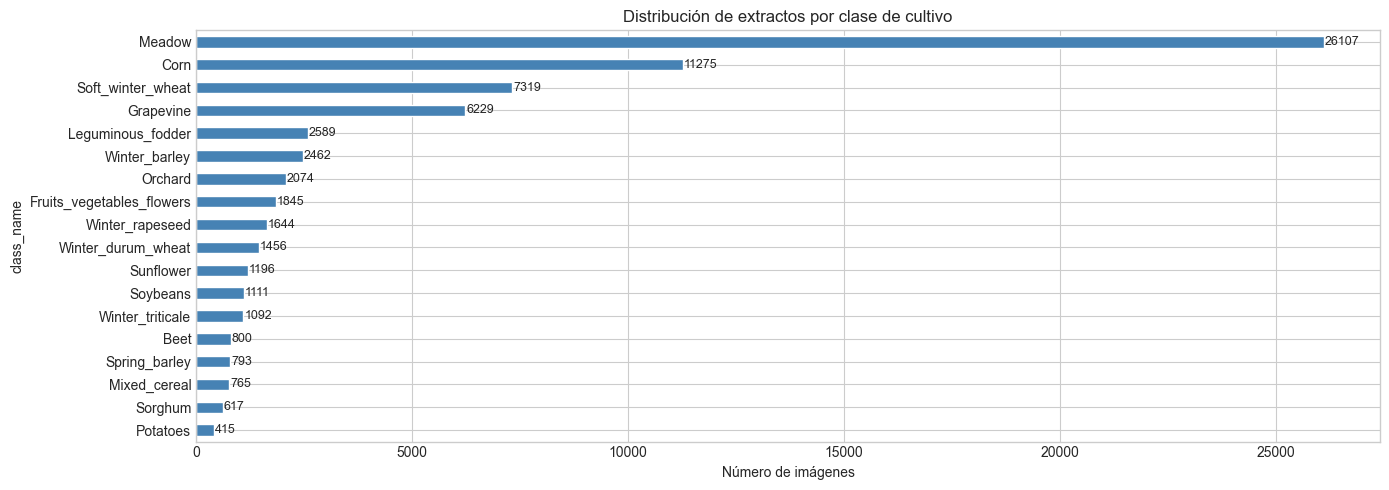


Resumen guardado en: train_data_v0\summary.json


In [35]:
# ============================================================
# RESUMEN Y ESTADÍSTICAS
# ============================================================

df_records = pd.DataFrame(all_records, columns=["class_id", "patch_id", "inst_id", "h", "w"])
df_records["class_name"] = df_records["class_id"].map(CLASS_FOLDER)
df_records["area_px"] = df_records["h"] * df_records["w"]

# --- Tabla resumen por clase ---
summary = (
    df_records
    .groupby(["class_id", "class_name"])
    .agg(
        n_images=("inst_id", "count"),
        avg_h=("h", "mean"),
        avg_w=("w", "mean"),
        avg_area=("area_px", "mean"),
    )
    .round(1)
    .sort_values("n_images", ascending=False)
)

print("=" * 70)
print(f"  RESUMEN DE EXTRACCIÓN  —  {len(all_records):,} imágenes totales")
print("=" * 70)
print(summary.to_string())

# --- Gráfica de distribución ---
fig, ax = plt.subplots(figsize=(14, 5))
counts = df_records["class_name"].value_counts().sort_values()
counts.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Número de imágenes")
ax.set_title("Distribución de extractos por clase de cultivo")
for i, v in enumerate(counts):
    ax.text(v + 20, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

# --- Guardar resumen JSON ---
summary_dict = {
    "total_images": len(all_records),
    "total_patches": len(patch_ids),
    "min_parcel_px": MIN_PARCEL_PX,
    "classes": {
        CLASS_FOLDER[cid]: int(cnt)
        for cid, cnt in df_records["class_id"].value_counts().items()
    },
}
summary_path = OUTPUT_DIR / "summary.json"
with open(summary_path, "w") as f:
    json.dump(summary_dict, f, indent=2)
print(f"\nResumen guardado en: {summary_path}")

---
## 4. Conclusiones — Preparacion de Datos (CRISP-ML)

### 4.1 Hallazgos de calidad de datos

| Aspecto | Observacion |
|---------|-------------|
| **Integridad** | 2,468 patches cargados sin archivos corruptos ni valores NaN. Datos Sentinel-2 en int16 y Sentinel-1 en float16 dentro de rangos esperados. |
| **Resolucion espacial** | Fija en 128x128 pixeles (10 m/px = 1.28 km x 1.28 km). No hay datos faltantes por patch ni variacion en la grilla. |
| **Series temporales** | Longitud variable entre patches (38-61 adquisiciones S2, ~65-70 S1). La reduccion temporal con media/std/max colapsa esta variabilidad a features de dimension fija. |
| **Artefactos atmosfericos** | La presencia de nubes y sombras en timestamps individuales se mitiga con la mediana temporal usada para la extraccion de imagenes RGB (seccion 3). |
| **Anotaciones** | Mascaras semanticas con 20 clases y mascaras de instancia con ~110 parcelas por patch. Cobertura agricola promedio del ~80% por patch. |

### 4.2 Balance de clases

El dataset presenta un **desbalance importante** entre clases de cultivo:

| Posicion | Clase | Imagenes | Ratio vs menor |
|----------|-------|----------|---------------|
| Mayor | Meadow | 26,107 | 63:1 |
| 2do | Corn | 11,275 | 27:1 |
| 3ro | Soft winter wheat | 7,319 | 18:1 |
| ... | ... | ... | ... |
| Menor | Potatoes | 415 | 1:1 |

- **Clases excluidas:** Background (0) y Void (19) no representan cultivos agricolas. El Void corresponde a parcelas que se extienden fuera del borde del patch.
- **Implicacion para CLIP:** Sin mitigacion, el modelo tendera a predecir las clases mayoritarias (Meadow, Corn, Wheat). Se recomienda emplear *stratified sampling*, *class-weighted loss*, o *data augmentation* selectivo en las clases minoritarias durante el entrenamiento.

### 4.3 Decisiones de limpieza y transformacion

| Etapa | Parametro | Justificacion | Efecto |
|-------|-----------|---------------|--------|
| Exclusion de Background | clase == 0 | Pixeles no agricolas distorsionan estadisticas | Eliminados del analisis de features |
| Exclusion de Void | clase == 19 | Parcelas incompletas en bordes de patch | Eliminados de la extraccion de imagenes |
| Filtro de parcelas | bbox < 8x8 px | Fragmentos de <80x80 m no son representativos de un cultivo | ~3% de parcelas excluidas |
| StandardScaler | media=0, var=1 | Homogeniza escalas para PowerTransformer y PCA | Centrado y escalado |
| PowerTransformer | Yeo-Johnson | Normaliza distribuciones asimetricas; soporta valores negativos (NDVI, datos centrados) | Features ~normales |
| VarianceThreshold | 0.01 | Red de seguridad contra features constantes | 31 → 31 (ninguna eliminada) |
| Filtro de correlacion | Pearson > 0.9 | Elimina redundancia espectral entre bandas cercanas | 31 → 9 features |
| ANOVA (F-classif) | k='all' | Ranking diagnostico de poder discriminativo | 9 → 9 (informativo) |
| PCA | 95% varianza | Compresion final preservando informacion clave | 9 → 6 componentes |

### 4.4 Impacto en el pipeline downstream

- **Datos de entrenamiento listos:** 69,789 imagenes RGB en estructura ImageFolder (`./train_data_v0/`), directamente compatible con `torchvision.datasets.ImageFolder` y el pipeline de CLIP.
- **Resize en DataLoader:** El tamano nativo de las parcelas (~20x20 px, resolucion inherente de Sentinel-2 a 10 m/px) requiere un resize a 224x224 durante el entrenamiento. Esta operacion se realiza en el DataLoader para preservar los datos originales.
- **Informacion espectral:** El analisis de features de la seccion 2 identifica que las bandas NIR (B8, B8A) y el NDVI son los indicadores mas discriminativos entre clases de cultivo, informacion util para diseñar text prompts especificos por clase en CLIP.
- **Folds de validacion:** El dataset PASTIS incluye 5 folds oficiales (en `metadata.geojson`) que se deben respetar para evaluacion justa, evitando fuga de datos entre patches geograficamente cercanos.

### 4.5 Riesgos identificados

| Riesgo | Severidad | Mitigacion propuesta |
|--------|-----------|---------------------|
| Desbalance de clases (63:1) sesga el modelo hacia Meadow/Corn/Wheat | Alta | Weighted sampling, focal loss, o oversampling de clases minoritarias |
| Parcelas pequenas (~20x20 px) pierden textura al hacer resize a 224x224 | Media | Usar interpolacion bicubica; evaluar si agregar contexto espacial del entorno mejora la clasificacion |
| Bounding box rectangular incluye pixeles de parcelas vecinas | Media | Considerar aplicar la mascara de instancia para enmascarar pixeles externos (fondo negro o inpainting) |
| Sobreajuste geografico (solo region de Francia) | Alta | Validar con datos de otras regiones; usar text prompts genericos por tipo de cultivo en CLIP |
| Variabilidad temporal no capturada en imagenes RGB estaticas | Baja | La mediana temporal resume el ciclo agricola; para capturar fenologia, se podrian agregar canales temporales adicionales |